In [1]:
import pandas as pd
import matplotlib as plt
from metrics import metrics
from model import generics
pd.set_option('display.max_rows', 2000)

%load_ext autoreload
%autoreload 2

ModuleNotFoundError: No module named 'metrics'

In [7]:
experiment_id = 'chamados'

In [14]:
df_mean_metrics, df_all_metrics, df_prevs = metrics.open_fold_result(experiment_id)

In [15]:
#df_mean_metrics.reset_index().sort_values(by=['ts', 'model']).to_csv('temp.csv')

In [16]:
df_mean_metrics.reset_index().sort_values(by=['ts', 'model'])#[df_mean_metrics.reset_index()['model'].str.contains("mlp-").values]
#usadas no artigo Airlines River Lake Milk Ozone Paper PollutionStar Sunspot Temperature

,ts,model,MSE,RMSE,MAPE,MAE,theil,ARV,IA,POCID,val_metric,time_testing,time_training
0,majaboataosamu,1am,1.670882,1.292626,1.980459,1.051163,0.410300,0.141034,0.964248,64.915254,1.348387,0.000309,0.282329
1,majaboataosamu,1ammean20,1.670089,1.292319,1.983227,1.051814,0.423407,0.143990,0.963875,65.254237,1.345297,0.003773,0.081110
2,majaboataosamu,1ammean40,1.667837,1.291447,1.982193,1.051313,0.420201,0.143601,0.963951,65.084746,1.345232,0.004234,0.111503
3,majaboataosamu,1ammean80,1.667508,1.291319,1.985150,1.052235,0.428601,0.145686,0.963691,65.677966,1.345478,0.007482,0.152905
4,majaboataosamu,1aqmean20,1.665823,1.290666,1.981748,1.048203,0.458409,0.156612,0.962391,66.949153,1.353673,0.001821,0.051278
5,majaboataosamu,1aqmean40,1.668078,1.291541,1.984374,1.049488,0.459030,0.156792,0.962342,66.949153,1.353893,0.004573,0.124141
6,majaboataosamu,1aqmean80,1.665500,1.290542,1.981599,1.048130,0.458320,0.156587,0.962398,66.949153,1.353840,0.007465,0.158465
7,majaboataosamu,1arima,1.707739,1.306805,2.022564,1.068524,0.469944,0.159923,0.961489,66.949153,inf,inf,inf
8,majaboataosamu,1arimaeml,1.738926,1.318678,2.000694,1.062465,0.420720,0.140289,0.963597,64.322034,1.334731,0.000141,0.037171
9,majaboataosamu,1as,1.644060,1.282209,1.955092,1.037485,0.395282,0.138073,0.964913,66.949153,1.341691,0.001619,0.019746


In [5]:
metric = 'RMSE'

proposed_list = []
for k, df in df_mean_metrics.reset_index().groupby('ts'):
    #arima = df[df['model'] == 'arima'][metric].iloc[0]
    #svr = df[df['model'] == 'arima'][metric].iloc[0]
    #mlp = df[df['model'] == 'arima'][metric].iloc[0]

    #df_arima[k] = (df.set_index('model')[metric] < arima)
    #df_svr[k] = (df.set_index('model')[metric] < svr)
    #df_mlp[k] = (df.set_index('model')[metric] < mlp)

    svr_proposed = df[( (df['model'].str.contains("1ammeanenscdsrc12k10")))].copy()
    if svr_proposed.shape[0]>0:
        proposed_list.append(pd.DataFrame(svr_proposed.iloc[svr_proposed['val_metric'].argmin()]).T)

    mlp_proposed = df[( (df['model'].str.contains("mlpkpssfalsep")) )].copy()
    if mlp_proposed.shape[0]>0:
        proposed_list.append(pd.DataFrame(mlp_proposed.iloc[mlp_proposed['val_metric'].argmin()]).T)

    proposed_list.append(
        df[df['model'].isin(
            [ '1svr', '1arima', '1arimamlp', '1amens', '1asens', '1as', '1am']
        )]
    )

In [6]:
pd.concat(proposed_list)

,ts,model,MSE,RMSE,MAPE,MAE,theil,ARV,IA,POCID,val_metric,time_testing,time_training
3,Unemployment,1ammeanenscdsrc12k10,1319.182521,36.304585,4.409001,26.765456,0.310659,0.093315,0.977213,68.333333,17.883327,inf,inf
0,Unemployment,1am,1355.859735,36.821928,4.44374,27.018404,0.315899,0.090815,0.977188,70.833333,25.701975,0.000218,0.088543
21,Unemployment,1arima,3367.940389,58.033959,6.515261,42.026475,0.471769,0.210969,0.943804,70.833333,inf,inf,inf
23,Unemployment,1as,1322.241377,36.362637,4.599497,28.307749,0.285973,0.089732,0.977632,66.666667,26.40228,0.000256,0.001933
25,Unemployment,1asens,1643.764815,40.529123,4.862633,29.981828,0.326211,0.115321,0.971645,69.166667,29.002039,0.033951,0.115142
39,Unemployment,1svr,1056.384751,32.502073,4.101036,24.105751,0.238184,0.074374,0.981888,66.666667,22.476597,0.000589,0.015608
40,ausbee,1am,257.127874,16.033896,2.685414,11.187198,0.094734,0.176233,0.947829,95.238095,14.894268,0.000199,0.053449
61,ausbee,1arima,275.147801,16.58758,3.128794,13.102531,0.111015,0.210175,0.94039,95.238095,inf,inf,inf
63,ausbee,1as,284.187885,16.857873,2.857842,11.813287,0.102074,0.188851,0.943145,95.238095,14.745258,0.000314,0.00164
65,ausbee,1asens,265.344329,16.289231,3.084943,12.927774,0.106088,0.201373,0.942806,95.238095,14.383242,0.040085,0.057557


In [34]:
for key, df_serie in df_all_metrics.groupby(['ts']):
    break

In [39]:
df_serie.pivot(columns= 'model', values='MAPE' )

model,1am,1arima,1arimaeml,1as,1deepar,1elm,1kan,1ma,1mlp,1nhits,1rw,1svr,1tcn
0,1.979973,2.022564,2.000167,1.955092,2.674332,2.784598,2.886893,5.159253,2.816651,2.842089,2.841743,2.781591,3.041359
1,1.980497,NaN,2.013922,NaN,2.702999,2.836056,2.907643,NaN,2.897807,2.835499,NaN,NaN,2.898116
2,1.980937,NaN,1.992450,NaN,2.643382,2.817253,2.875357,NaN,2.764071,2.865236,NaN,NaN,2.951085
3,1.980457,NaN,1.991128,NaN,2.627743,2.818880,2.875453,NaN,2.835771,2.843746,NaN,NaN,2.917378
4,1.980563,NaN,1.995838,NaN,2.676614,2.847102,2.902828,NaN,2.845818,2.857558,NaN,NaN,2.973094
5,1.980077,NaN,2.021492,NaN,2.674554,2.914566,2.883034,NaN,2.832117,2.850648,NaN,NaN,2.910988
6,1.979662,NaN,1.992706,NaN,2.662191,2.841000,2.890364,NaN,2.884835,2.840435,NaN,NaN,3.006825
7,1.980703,NaN,2.000313,NaN,2.666116,2.827184,2.886079,NaN,2.802259,2.829291,NaN,NaN,2.949030
8,1.980705,NaN,1.999800,NaN,2.675494,2.780729,2.898030,NaN,2.825014,2.859317,NaN,NaN,3.123197
9,1.981020,NaN,1.999128,NaN,2.721175,2.855920,2.895843,NaN,2.817721,2.856015,NaN,NaN,2.822762


<Axes: >

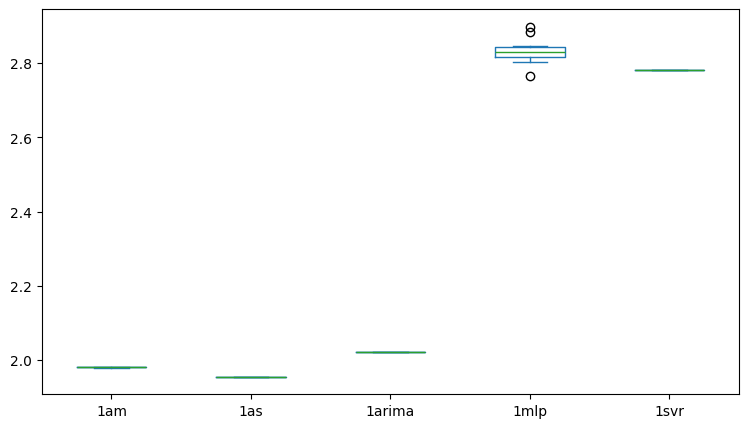

In [46]:
df_serie.pivot(columns= 'model', values='MAPE' )[['1am', '1as', '1arima', '1mlp', '1svr']].plot.box(figsize = (9,5))